# Code - Modality 1 (DeepFashion images), Flow Matching


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Unzip data file from drive

In [2]:
!unzip -q "/content/drive/MyDrive/CIS 6270/CIS 6270 Project 1/DeepFashion.zip" -d "/content/"

In [3]:
# Imports and shared settings
from pathlib import Path
import math
import random
import time
from collections import defaultdict

import numpy as np
from PIL import Image, ImageOps
import torch
from torch.utils.data import DataLoader, Dataset, Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42
image_size = 64
batch_size = 64
num_classes = 50
null_class = num_classes
data_root = Path("DeepFashion")
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)


In [4]:
print(f"Using device: {device}")

Using device: cuda


In [5]:
# Load DeepFashion
def read_rows(path):
    with Path(path).open(encoding="utf-8") as file:
        next(file)  # Number of records.
        next(file)  # Column names.
        for line in file:
            if line.strip():
                yield line.split()


class FashionDataset(Dataset):
    def __init__(self, root, split, image_size=64, flip=False, limit=0, seed=42):
        self.root = Path(root)
        self.image_size = image_size
        self.flip = flip
        annotation = self.root / "Anno_coarse"
        self.classes = [" ".join(row[:-1]) for row in read_rows(annotation / "list_category_cloth.txt")]
        labels = {row[0]: int(row[1]) - 1 for row in read_rows(annotation / "list_category_img.txt")}
        boxes = {row[0]: tuple(map(int, row[1:5])) for row in read_rows(annotation / "list_bbox.txt")}
        self.records = [(path, labels[path], boxes[path])
                        for path, partition in read_rows(self.root / "Eval/list_eval_partition.txt")
                        if partition == split and path in labels and path in boxes]
        if not self.records:
            raise ValueError(f"No {split} images found under {self.root}")
        if limit and limit < len(self.records):
            # The small validation set stays balanced across the available classes.
            groups = defaultdict(list)
            for record in self.records:
                groups[record[1]].append(record)
            rng = random.Random(seed)
            for group in groups.values():
                rng.shuffle(group)
            selected = []
            class_ids = sorted(groups)
            while len(selected) < limit and class_ids:
                for class_id in class_ids[:]:
                    if len(selected) == limit:
                        break
                    if groups[class_id]:
                        selected.append(groups[class_id].pop())
                    else:
                        class_ids.remove(class_id)
            self.records = selected

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        relative_path, label, (x1, y1, x2, y2) = self.records[index]
        with Image.open(self.root / relative_path) as source:
            image = source.convert("RGB")
            x1, x2 = max(0, x1), min(image.width, x2)
            y1, y2 = max(0, y1), min(image.height, y2)
            if x2 > x1 and y2 > y1:
                image = image.crop((x1, y1, x2, y2))
            image = ImageOps.pad(image, (self.image_size, self.image_size),
                                 method=Image.Resampling.BICUBIC, color=(255, 255, 255))
            if self.flip and random.random() < 0.5:
                image = ImageOps.mirror(image)
            pixels = np.asarray(image, dtype=np.uint8).copy()
        # Convert RGB pixels to [-1, 1].
        x0 = torch.from_numpy(pixels).permute(2, 0, 1).float().div_(127.5).sub_(1)
        return x0, label


train_data = FashionDataset(data_root, "train", image_size, flip=True)
val_data = FashionDataset(data_root, "val", image_size, limit=2048, seed=seed)
active_class_ids = sorted({label for _, label, _ in train_data.records})
class_names = train_data.classes
assert len(class_names) == num_classes

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=(device.type == "cuda"))
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=(device.type == "cuda"))


Train: 209,222; validation: 2,048; active classes: 46 of 50


In [6]:
import csv

captions_path = data_root / "captions.csv"
with captions_path.open(encoding="utf-8-sig", newline="") as file:
    reader = csv.DictReader(file)
    if reader.fieldnames != ["image_path", "caption"]:
        raise ValueError(f"Unexpected caption columns: {reader.fieldnames}")
    captions_by_image = {row["image_path"]: row["caption"] for row in reader}

example_path = train_data.records[0][0]


Loaded 289,222 captions
Example — img/Sheer_Pleated-Front_Blouse/img_00000001.jpg: This is a pleated sheer blouse.


In [7]:
def Sample_Conditional_Path(x1):
    x0 = torch.randn_like(x1)                     # (B, C, H, W])
    t = torch.rand(x1.shape[0], device=x1.device)  # (B)
    t_expanded = t[:, None, None, None]            # (B, 1, 1, 1)
    xt = (1.0 - t_expanded) * x0 + t_expanded * x1
    ut = x1 - x0
    return xt, t, ut

In [8]:
# init flow matching unet
from torch import nn
import torch.nn.functional as F

BASE_CHANNELS = 64
NUM_CLASSES = num_classes
NULL_CLASS_IDX = null_class #cfg null token
COND_EMBED_DIM = 32
TIME_EMBED_DIM = 64
NUM_CHANNELS = 3


def sinusoidal_time_embedding(t, dim):
    half_dim = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half_dim, device=t.device, dtype=torch.float32) / half_dim
    )
    args = t.float()[:, None] * freqs[None, :]
    embedding = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    if dim % 2 == 1:
        embedding = F.pad(embedding, (0, 1))
    return embedding

def _num_groups(channels, target=8):
    for g in (target, 4, 2, 1):
        if channels % g == 0:
            return g
    return 1

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.norm1 = nn.GroupNorm(_num_groups(in_channels), in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.norm2 = nn.GroupNorm(_num_groups(out_channels), out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.skip = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        h = self.conv1(F.silu(self.norm1(x)))
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class SelfAttention2d(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(_num_groups(channels), channels)
        self.mha = nn.MultiheadAttention(channels, num_heads, batch_first=True)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x).flatten(2).transpose(1, 2)
        attn_out, _ = self.mha(h, h, h)
        attn_out = attn_out.transpose(1, 2).reshape(B, C, H, W)
        return x + attn_out


class FullyConnectedUNet(nn.Module):
    def __init__(self, base_channels=BASE_CHANNELS, num_classes=NUM_CLASSES,
                 cond_embed_dim=COND_EMBED_DIM, time_embed_dim=TIME_EMBED_DIM):
        super().__init__()
        c = base_channels
        self.time_embed_dim = time_embed_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(time_embed_dim, time_embed_dim),
            nn.SiLU(),
            nn.Linear(time_embed_dim, time_embed_dim),
        )
        self.class_embed = nn.Embedding(num_classes + 1, cond_embed_dim)  # +1 for cfg null token
        self.enc1 = ResBlock(NUM_CHANNELS + time_embed_dim + cond_embed_dim, c)
        self.enc2 = ResBlock(c, 2 * c)
        self.middle = ResBlock(2 * c, 4 * c)
        self.middle_attn = SelfAttention2d(4 * c)
        self.dec2 = ResBlock(6 * c, 2 * c)
        self.dec1 = ResBlock(3 * c, c)
        self.output = nn.Conv2d(c, NUM_CHANNELS, 1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, xt, t, y):
        t_emb = self.time_mlp(sinusoidal_time_embedding(t, self.time_embed_dim))
        t_image = t_emb[:, :, None, None].expand(-1, -1, xt.shape[2], xt.shape[3])
        class_image = self.class_embed(y)[:, :, None, None].expand(-1, -1, xt.shape[2], xt.shape[3])
        x = torch.cat([xt, t_image, class_image], dim=1)
        skip1 = self.enc1(x)                    # shape: (B, c, 64, 64)
        skip2 = self.enc2(self.pool(skip1))     # (B, 2c, 32, 32)
        x = self.middle(self.pool(skip2))       # (B, 4c, 16, 16)
        x = self.middle_attn(x)                 # bottleneck with attention
        x = F.interpolate(x, size=skip2.shape[-2:], mode="nearest")
        x = self.dec2(torch.cat([x, skip2], dim=1))
        x = F.interpolate(x, size=skip1.shape[-2:], mode="nearest")
        x = self.dec1(torch.cat([x, skip1], dim=1))
        return self.output(x)                   # (B, 3, 64, 64)

model = FullyConnectedUNet().to(device)
print(f"Num param: {sum(p.numel() for p in model.parameters()):,}")

Number of parameters: 2,324,585


In [9]:
lr = 2e-4
drop_class_percentage = 0.1
num_epochs = 50
patience = 10
min_delta = 1e-4
ema_decay = 0.999
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))
loss_fn = nn.MSELoss()
best_val = significant_best = float("inf")
stale_epochs = 0
best_weights = None

class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if v.dtype.is_floating_point:
                self.shadow[k].mul_(self.decay).add_(v, alpha=1 - self.decay)
            else:
                self.shadow[k] = v.clone()

    def copy_to(self, model):
        model.load_state_dict(self.shadow, strict=True)

ema = EMA(model, decay=ema_decay)
ema_model = FullyConnectedUNet().to(device)
ema.copy_to(ema_model)


@torch.no_grad()
def Validation_MSE(net):
    net.eval()
    rng = torch.Generator(device=device).manual_seed(seed + 1000)
    total_squared_error = num_pixels = 0
    for images, labels in val_loader:
        x1, labels = images.to(device), labels.to(device)
        x0 = torch.randn(x1.shape, device=device, generator=rng)
        t = torch.rand(len(x1), device=device, generator=rng)
        t_expanded = t[:, None, None, None]
        xt = (1 - t_expanded) * x0 + t_expanded * x1
        ut = x1 - x0
        predicted = net(xt, t, labels)
        total_squared_error += F.mse_loss(predicted.float(), ut, reduction="sum").item()
        num_pixels += ut.numel()
    return total_squared_error / num_pixels


for epoch in range(num_epochs):
    model.train()
    total_loss = num_images = 0
    for images, labels in train_loader:  # flip horizontally random images for more variability
        x1, labels = images.to(device), labels.to(device)
        xt, t, ut = Sample_Conditional_Path(x1)
        dropped = torch.rand(len(x1), device=device) < drop_class_percentage
        model_labels = labels.masked_fill(dropped, null_class)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            predicted_velocity = model(xt, t, model_labels)
            loss = loss_fn(predicted_velocity.float(), ut.float())
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)
        total_loss += loss.item() * len(x1)
        num_images += len(x1)
    scheduler.step()

    # early stopping
    ema.copy_to(ema_model)
    val_mse = Validation_MSE(ema_model)
    if val_mse < best_val:
        best_val = val_mse
        best_weights = {name: tensor.detach().cpu().clone()
                        for name, tensor in ema_model.state_dict().items()}
    if val_mse < significant_best - min_delta:
        significant_best, stale_epochs = val_mse, 0
    else:
        stale_epochs += 1
    print(f"Epoch {epoch + 1}: train MSE={total_loss / num_images:.5f}, "
          f"validation MSE (EMA)={val_mse:.5f}, best={best_val:.5f}")
    if patience and stale_epochs >= patience:
        print(f"Early stopping after {epoch + 1} epochs")
        break

if best_weights is not None:
    ema_model.load_state_dict(best_weights)
ema_model.eval()

Epoch 1: train MSE=0.19695, validation MSE (EMA)=0.15966, best=0.15966
Epoch 2: train MSE=0.13800, validation MSE (EMA)=0.13139, best=0.13139
Epoch 3: train MSE=0.12893, validation MSE (EMA)=0.12390, best=0.12390
Epoch 4: train MSE=0.12407, validation MSE (EMA)=0.11983, best=0.11983
Epoch 5: train MSE=0.12085, validation MSE (EMA)=0.11719, best=0.11719
Epoch 6: train MSE=0.11916, validation MSE (EMA)=0.11506, best=0.11506
Epoch 7: train MSE=0.11719, validation MSE (EMA)=0.11366, best=0.11366
Epoch 8: train MSE=0.11592, validation MSE (EMA)=0.11249, best=0.11249
Epoch 9: train MSE=0.11491, validation MSE (EMA)=0.11144, best=0.11144
Epoch 10: train MSE=0.11393, validation MSE (EMA)=0.11065, best=0.11065
Epoch 11: train MSE=0.11296, validation MSE (EMA)=0.10991, best=0.10991
Epoch 12: train MSE=0.11264, validation MSE (EMA)=0.10935, best=0.10935
Epoch 13: train MSE=0.11187, validation MSE (EMA)=0.10882, best=0.10882
Epoch 14: train MSE=0.11170, validation MSE (EMA)=0.10842, best=0.10842
E

FullyConnectedUNet(
  (time_mlp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): SiLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  )
  (class_embed): Embedding(51, 32)
  (enc1): ResBlock(
    (norm1): GroupNorm(1, 99, eps=1e-05, affine=True)
    (conv1): Conv2d(99, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (skip): Conv2d(99, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (enc2): ResBlock(
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (skip): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (middle): ResBlock(
    (norm1): GroupNorm(8, 128, eps=1e-05, affine

In [10]:
# save model
torch.save({"model": model.state_dict(), "ema_model": ema_model.state_dict()},
           "fashion_flow_matching_best.pt")

In [11]:
@torch.no_grad()
def Sample_Images(net, class_labels, guidance_scale=3.0, generator=None, sample_steps=100):
    net.eval()
    class_labels = torch.as_tensor(class_labels, device=device, dtype=torch.long)
    if sample_steps < 1:
        raise ValueError("sample_steps must be at least 1")
    if any(label.item() not in active_class_ids for label in class_labels):
        raise ValueError("A requested class has no training images")
    batch = len(class_labels)
    null_labels = torch.full_like(class_labels, null_class)
    xt = torch.randn(batch, 3, image_size, image_size, device=device, generator=generator)
    dt = 1.0 / sample_steps

    for step in range(sample_steps):
        t = torch.full((batch,), step * dt, device=device)
        if guidance_scale == 0:
            velocity = net(xt, t, null_labels)
        elif guidance_scale == 1:
            velocity = net(xt, t, class_labels)
        else:
            pair = net(torch.cat([xt, xt]), torch.cat([t, t]),
                       torch.cat([null_labels, class_labels]))
            unconditioned, conditioned = pair.chunk(2)
            velocity = unconditioned + guidance_scale * (conditioned - unconditioned)
        xt = xt + velocity * dt
    return xt.clamp(-1, 1)

# Experiments - Modality 1 (Images)

## Experiment 1. Flow Matching Baseline Evaluation

In [12]:
!pip install torchmetrics torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 10.5 MB/s eta 0:00:00


In [13]:

from torchmetrics.image.fid import FrechetInceptionDistance


In [14]:
num_eval = len(val_data)  # 2,048 validation img
eval_batch_size = 16
eval_seed = 123
sample_steps = 100  # Euler steps
reference_labels = [label for _, label, _ in val_data.records]


In [15]:
def To_FID_Format(images):
    return ((images.clamp(-1, 1) + 1) * 127.5).round().to(torch.uint8)

fid = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
fid.set_dtype(torch.float64)
with torch.no_grad():
    for real_images, _ in val_loader:
        fid.update(To_FID_Format(real_images.to(device)), real=True)

generator = torch.Generator(device=device).manual_seed(eval_seed)
if device.type == "cuda":
    torch.cuda.synchronize()
start_time = time.perf_counter()

for start in range(0, num_eval, eval_batch_size):
    count = min(eval_batch_size, num_eval - start)
    labels = torch.full((count,), active_class_ids[0], device=device, dtype=torch.long)
    generated = Sample_Images(ema_model, labels, guidance_scale=0.0,
                              generator=generator, sample_steps=sample_steps)
    fid.update(To_FID_Format(generated), real=False)

if device.type == "cuda":
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time
print(f"Validation FID without guidance: {fid.compute().item():.2f}")
print(f"Sampling time: {elapsed:.1f} seconds for {num_eval} images")
print(f"Model evaluations per image: {sample_steps}")


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:02<00:00, 40.0MB/s]


Validation FID without guidance: 48.36
Sampling time: 50.7 seconds for 2048 images
Model evaluations per image: 100


## Experiment 2. Evaluate classifier free guidancse

In [16]:
labels = torch.tensor(reference_labels, device=device, dtype=torch.long)

for guidance_scale in [1.0, 3.0]:
    guided_fid = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    guided_fid.set_dtype(torch.float64)
    with torch.no_grad():
        for real_images, _ in val_loader:
            guided_fid.update(To_FID_Format(real_images.to(device)), real=True)
    generator = torch.Generator(device=device).manual_seed(eval_seed)
    if device.type == "cuda":
        torch.cuda.synchronize()
    start_time = time.perf_counter()
    for start in range(0, num_eval, eval_batch_size):
        batch_labels = labels[start:start + eval_batch_size]
        generated = Sample_Images(ema_model, batch_labels, guidance_scale=guidance_scale,
                                  generator=generator, sample_steps=sample_steps)
        guided_fid.update(To_FID_Format(generated), real=False)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start_time
    print(f"Guidance {guidance_scale:g}: validation FID={guided_fid.compute().item():.2f}")
    print(f"Sampling time: {elapsed:.1f} seconds; model evaluations per image: "
          f"{sample_steps if guidance_scale == 1 else 2 * sample_steps}")


Guidance 1: validation FID=43.48
Sampling time: 50.6 seconds; model evaluations per image: 100
Guidance 3: validation FID=30.93
Sampling time: 86.4 seconds; model evaluations per image: 200


# Additional Experiments

Labels used to generate each image (guidance scale 3, 100 Euler steps):
  Image  1: category 0 = 'Anorak'
  Image  2: category 1 = 'Blazer'
  Image  3: category 2 = 'Blouse'
  Image  4: category 3 = 'Bomber'
  Image  5: category 4 = 'Button-Down'
  Image  6: category 5 = 'Cardigan'
  Image  7: category 6 = 'Flannel'
  Image  8: category 7 = 'Halter'
  Image  9: category 8 = 'Henley'
  Image 10: category 9 = 'Hoodie'
  Image 11: category 10 = 'Jacket'
  Image 12: category 11 = 'Jersey'
  Image 13: category 12 = 'Parka'
  Image 14: category 13 = 'Peacoat'
  Image 15: category 14 = 'Poncho'
  Image 16: category 15 = 'Sweater'
(Each image was also run once with the unconditional 'no category' token, which guidance contrasts against.)


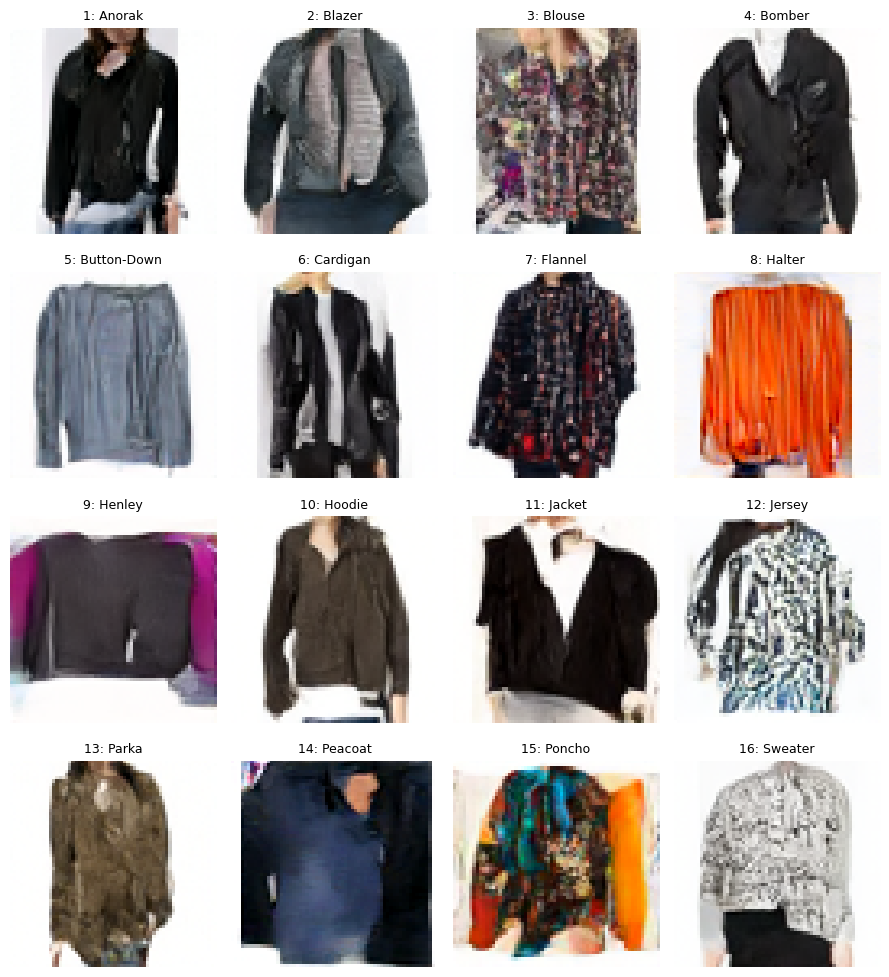

In [17]:
# Show samples from sixteen category IDs that have training images, and print the label used for each one.
import matplotlib.pyplot as plt

sample_guidance = 3.0
sample_label_ids = active_class_ids[:16]
sample_labels = torch.tensor(sample_label_ids, device=device)
sample_generator = torch.Generator(device=device).manual_seed(eval_seed)
samples = Sample_Images(ema_model, sample_labels, guidance_scale=sample_guidance,
                        generator=sample_generator, sample_steps=sample_steps)
display_images = ((samples.clamp(-1, 1) + 1) / 2).cpu()
for index, label_id in enumerate(sample_label_ids):
    print(f"  Image {index + 1:2d}: category {label_id} = '{class_names[label_id]}'")

fig, axes = plt.subplots(4, 4, figsize=(9, 10))
for index, ax in enumerate(axes.flat):
    ax.imshow(display_images[index].permute(1, 2, 0))
    ax.set_title(f"{index + 1}: {class_names[sample_label_ids[index]]}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Experiment 3. Classifier accuracy (top-1 / top-5)

Fine-tune a ResNet-18 on DeepFashion images and then use it to classify generated images. Report Top-1 accuracy as overall probability that true label was given the highest probability by the classifier given the generated image. Report Top-5 accuracy as overall probability that true label was in the top 5 highest probabilities generated by the classifier for a generated image.

note: requires fashion_resnet18_classifier.pt to be uploaded to current directory

In [21]:
from torchvision import models

clf_epochs = 10
clf_lr = 1e-3
clf_input_size = 128
clf_path = Path("fashion_resnet18_classifier.pt")


class FashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        x = (x.clamp(-1, 1) + 1) / 2
        x = F.interpolate(x, size=clf_input_size, mode="bilinear", align_corners=False)
        return self.backbone((x - self.mean) / self.std)

def Top_K_Hits(logits, labels, ks=(1, 5)):
    top = logits.topk(max(ks), dim=1).indices
    hits = top == labels[:, None]
    return [hits[:, :k].any(dim=1) for k in ks]





@torch.no_grad()
def Real_Val_Accuracy(classifier):
    classifier.eval()
    top1 = top5 = total = 0
    for images, batch_labels in val_loader:
        images, batch_labels = images.to(device), batch_labels.to(device)
        hit1, hit5 = Top_K_Hits(classifier(images), batch_labels)
        top1, top5, total = top1 + hit1.sum().item(), top5 + hit5.sum().item(), total + len(images)
    return top1 / total, top5 / total

classifier = FashionClassifier().to(device)
if clf_path.exists():
    classifier.load_state_dict(torch.load(clf_path, map_location=device))
    print(f"Loaded fine-tuned classifier from {clf_path}")
else:
    clf_optimizer = torch.optim.AdamW(classifier.parameters(), lr=clf_lr, weight_decay=1e-4)
    clf_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(clf_optimizer, T_max=clf_epochs)
    clf_scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))
    for epoch in range(clf_epochs):
        classifier.train()
        total_loss = num_images = 0
        for images, batch_labels in train_loader:
            images, batch_labels = images.to(device), batch_labels.to(device)
            clf_optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                loss = F.cross_entropy(classifier(images).float(), batch_labels)
            clf_scaler.scale(loss).backward()
            clf_scaler.step(clf_optimizer)
            clf_scaler.update()
            total_loss += loss.item() * len(images)
            num_images += len(images)
        clf_scheduler.step()
        val_top1, val_top5 = Real_Val_Accuracy(classifier)
        print(f"Classifier epoch {epoch + 1}: train loss={total_loss / num_images:.4f}, "
              f"real validation top-1={val_top1:.3f}, top-5={val_top5:.3f}")
    torch.save(classifier.state_dict(), clf_path)
classifier.eval()

Classifier epoch 1: train loss=1.2576, real validation top-1=0.317, top-5=0.701
Classifier epoch 2: train loss=1.0699, real validation top-1=0.337, top-5=0.730
Classifier epoch 3: train loss=0.9784, real validation top-1=0.384, top-5=0.785
Classifier epoch 4: train loss=0.8988, real validation top-1=0.396, top-5=0.785
Classifier epoch 5: train loss=0.8083, real validation top-1=0.412, top-5=0.815
Classifier epoch 6: train loss=0.6979, real validation top-1=0.434, top-5=0.819
Classifier epoch 7: train loss=0.5651, real validation top-1=0.439, top-5=0.817
Classifier epoch 8: train loss=0.4201, real validation top-1=0.449, top-5=0.822
Classifier epoch 9: train loss=0.2970, real validation top-1=0.440, top-5=0.817
Classifier epoch 10: train loss=0.2259, real validation top-1=0.437, top-5=0.818


FashionClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True

In [22]:
eval_labels = torch.tensor(reference_labels, device=device, dtype=torch.long)
real_top1, real_top5 = Real_Val_Accuracy(classifier)
accuracy_results = {"real validation images": (real_top1, real_top5)}
per_class_hits = {}

for guidance_scale in [0.0, 1.0, 3.0]:
    print(f"Evaluating guidance {guidance_scale:g}...")
    generator = torch.Generator(device=device).manual_seed(eval_seed)
    hit1_all, hit5_all = [], []
    for start in range(0, num_eval, eval_batch_size):
        batch_labels = eval_labels[start:start + eval_batch_size]
        generated = Sample_Images(ema_model, batch_labels, guidance_scale=guidance_scale,
                                  generator=generator, sample_steps=sample_steps)
        with torch.no_grad():
            hit1, hit5 = Top_K_Hits(classifier(generated), batch_labels)
        hit1_all.append(hit1)
        hit5_all.append(hit5)
    hit1_all, hit5_all = torch.cat(hit1_all), torch.cat(hit5_all)
    accuracy_results[f"generated, guidance {guidance_scale:g}"] = (hit1_all.float().mean().item(),
                                                                   hit5_all.float().mean().item())
    per_class_hits[guidance_scale] = hit1_all.cpu()

print(f"{'Images':<30}{'Top-1':>8}{'Top-5':>8}")
for name, (top1, top5) in accuracy_results.items():
    print(f"{name:<30}{top1:>8.3f}{top5:>8.3f}")
print("Guidance 0 ignores the label, so its accuracy is the chance-level floor; real images are the ceiling.")

ref = torch.tensor(reference_labels)
rows = []
for class_id in sorted(set(reference_labels)):
    mask = ref == class_id
    if mask.sum() >= 10:
        rows.append((per_class_hits[3.0][mask].float().mean().item(), class_names[class_id], int(mask.sum())))
rows.sort()
print("\nLowest per-class top-1 accuracy at guidance 3:")
for accuracy, name, count in rows[:5]:
    print(f"  {name} ({count} images): {accuracy:.3f}")
print("Highest:")
for accuracy, name, count in rows[-5:][::-1]:
    print(f"  {name} ({count} images): {accuracy:.3f}")

Evaluating guidance 0...
Evaluating guidance 1...
Evaluating guidance 3...
Images                           Top-1   Top-5
real validation images           0.437   0.818
generated, guidance 0            0.029   0.133
generated, guidance 1            0.119   0.402
generated, guidance 3            0.242   0.614
Guidance 0 ignores the label, so its accuracy is the chance-level floor; real images are the ceiling.

Lowest per-class top-1 accuracy at guidance 3:
  Anorak (16 images): 0.000
  Button-Down (41 images): 0.000
  Capris (11 images): 0.000
  Cutoffs (59 images): 0.000
  Henley (60 images): 0.000
Highest:
  Dress (59 images): 0.932
  Tee (59 images): 0.644
  Tank (60 images): 0.633
  Jacket (60 images): 0.633
  Shorts (59 images): 0.610


Precision and Recall

In [24]:
pr_k = 3
feature_extractor = nn.Sequential(*list(classifier.backbone.children())[:-1]).to(device).eval()
@torch.no_grad()
def Classifier_Features(images):
    x = (images.clamp(-1, 1) + 1) / 2
    x = F.interpolate(x, size=clf_input_size, mode="bilinear", align_corners=False)
    return feature_extractor((x - classifier.mean) / classifier.std).flatten(1).float()
def KNN_Radii(features, k):
    distances = torch.cdist(features, features)
    return distances.kthvalue(k + 1, dim=1).values
def Precision_Recall(real_features, generated_features, k=3):
    real_radii = KNN_Radii(real_features, k)
    generated_radii = KNN_Radii(generated_features, k)
    distances = torch.cdist(real_features, generated_features)  # [num_real, num_generated]
    precision = (distances <= real_radii[:, None]).any(dim=0).float().mean().item()
    recall = (distances <= generated_radii[None, :]).any(dim=1).float().mean().item()
    return precision, recall

with torch.no_grad():
    real_features = torch.cat([Classifier_Features(images.to(device)) for images, _ in val_loader])

eval_labels = torch.tensor(reference_labels, device=device, dtype=torch.long)
pr_results = {}
for guidance_scale in [0.0, 1.0, 3.0]:
    generator = torch.Generator(device=device).manual_seed(eval_seed)
    generated_features = []
    for start in range(0, num_eval, eval_batch_size):
        generated = Sample_Images(ema_model, eval_labels[start:start + eval_batch_size],
                                  guidance_scale=guidance_scale, generator=generator, sample_steps=sample_steps)
        generated_features.append(Classifier_Features(generated))
    pr_results[guidance_scale] = Precision_Recall(real_features, torch.cat(generated_features), k=pr_k)

print(f"Precision / recall with k={pr_k}, {num_eval} real vs {num_eval} generated images")
print(f"{'Guidance':<10}{'Precision':>11}{'Recall':>9}")
for guidance_scale, (precision, recall) in pr_results.items():
    print(f"{guidance_scale:<10g}{precision:>11.3f}{recall:>9.3f}")

Precision / recall with k=3, 2048 real vs 2048 generated images
Guidance    Precision   Recall
0               0.742    0.481
1               0.741    0.577
3               0.842    0.566
Higher guidance usually raises precision and lowers recall (less diverse samples).
